In [70]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("cleaned_retail_1.csv")

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     53751
JUMBO BAG RED RETROSPOT               47256
POPCORN HOLDER                        36322
ASSORTED COLOUR BIRD ORNAMENT         36282
PACK OF 72 RETROSPOT CAKE CASES       36016
WHITE HANGING HEART T-LIGHT HOLDER    35294
RABBIT NIGHT LIGHT                    30631
MINI PAINT SET VINTAGE                26437
PACK OF 12 LONDON TISSUES             26095
PACK OF 60 PINK PAISLEY CAKE CASES    24719
Name: Quantity, dtype: int64


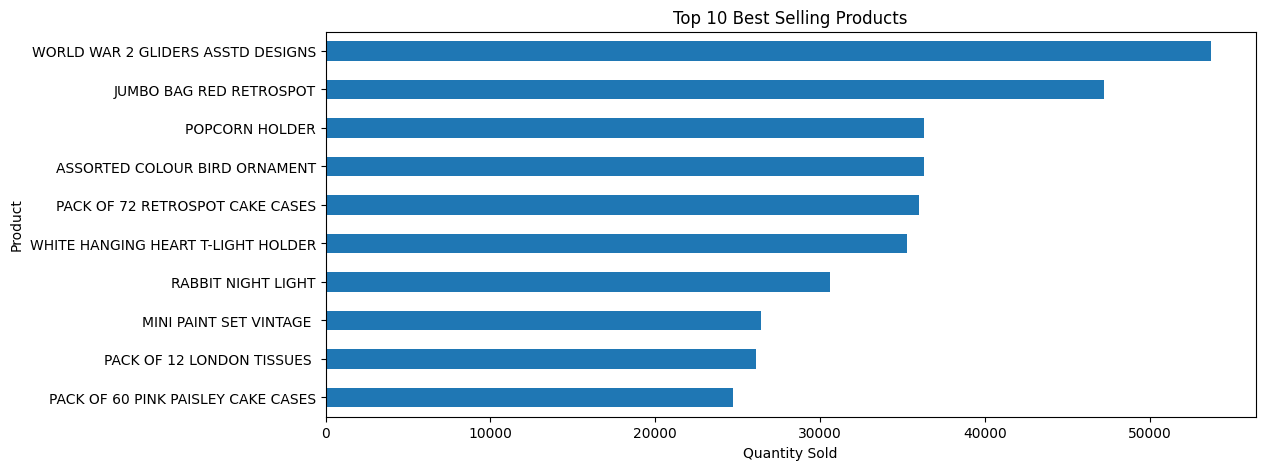

In [71]:
top_products = (
    df.groupby("Description")["Quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_products)

plt.figure(figsize=(12,5))
top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Best Selling Products")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")

plt.show()

Description
DOTCOM POSTAGE                        206245.48
REGENCY CAKESTAND 3 TIER              164459.49
WHITE HANGING HEART T-LIGHT HOLDER     99612.42
PARTY BUNTING                          98243.88
JUMBO BAG RED RETROSPOT                92175.79
RABBIT NIGHT LIGHT                     66661.63
POSTAGE                                66230.64
PAPER CHAIN KIT 50'S CHRISTMAS         63715.24
ASSORTED COLOUR BIRD ORNAMENT          58792.42
CHILLI LIGHTS                          53746.66
Name: TotalAmount, dtype: float64


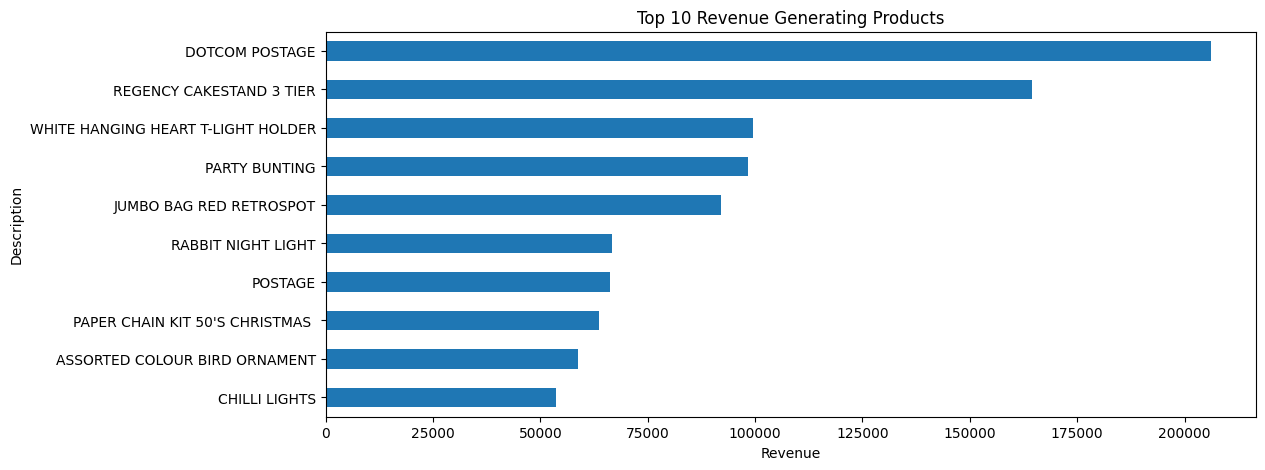

In [72]:
top_revenue = (
    df.groupby("Description")["TotalAmount"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_revenue)

plt.figure(figsize=(12,5))
top_revenue.sort_values().plot(kind="barh")

plt.title("Top 10 Revenue Generating Products")
plt.xlabel("Revenue")

plt.show()

Description
Discount                          -1194
SAMPLES                             -58
AMAZON FEE                          -30
ASSORTED TUTTI FRUTTI ROUND BOX     -24
CRUK Commission                     -16
Bank Charges                        -13
WHITE CHERRY LIGHTS                  -8
PINK POODLE HANGING DECORATION       -7
BLUE PADDED SOFT MOBILE              -6
WOODEN BOX ADVENT CALENDAR           -6
Name: Quantity, dtype: int64


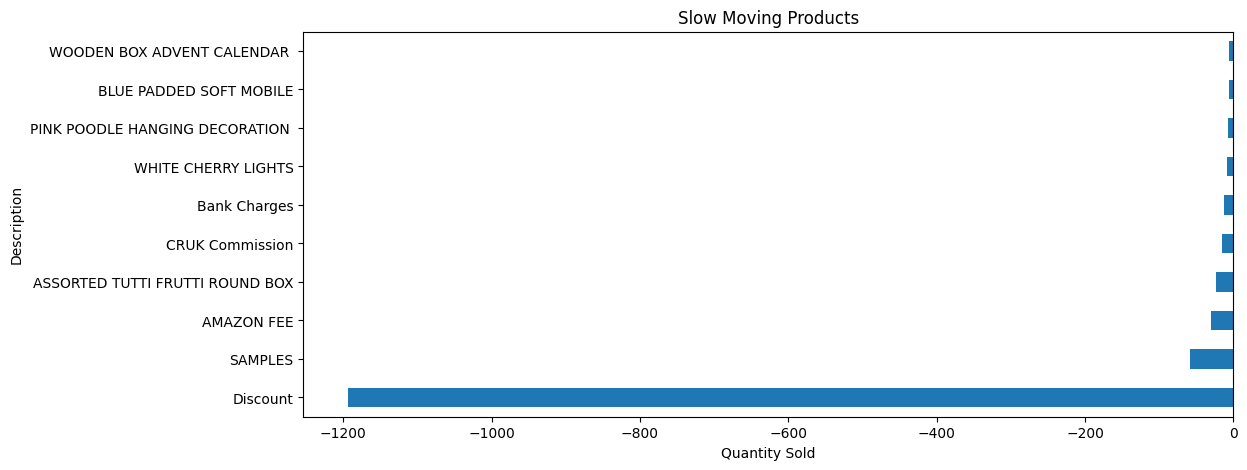

In [73]:
slow_products = (
    df.groupby("Description")["Quantity"]
      .sum()
      .sort_values()
      .head(10)
)

print(slow_products)

plt.figure(figsize=(12,5))
slow_products.plot(kind="barh")

plt.title("Slow Moving Products")
plt.xlabel("Quantity Sold")

plt.show()

In [74]:
abc = (
    df.groupby("Description")["TotalAmount"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

abc["Revenue_Percentage"] = (
    abc["TotalAmount"] /
    abc["TotalAmount"].sum()
)

abc["Cumulative_Percentage"] = (
    abc["Revenue_Percentage"].cumsum()
)

In [75]:
def abc_category(x):
    if x <= 0.80:
        return "A"
    elif x <= 0.95:
        return "B"
    else:
        return "C"

abc["Category"] = abc["Cumulative_Percentage"].apply(abc_category)

abc.head()

,Description,TotalAmount,Revenue_Percentage,Cumulative_Percentage,Category
0,DOTCOM POSTAGE,206245.48,0.021157,0.021157,A
1,REGENCY CAKESTAND 3 TIER,164459.49,0.016871,0.038028,A
2,WHITE HANGING HEART T-LIGHT HOLDER,99612.42,0.010219,0.048247,A
3,PARTY BUNTING,98243.88,0.010078,0.058325,A
4,JUMBO BAG RED RETROSPOT,92175.79,0.009456,0.067781,A


In [76]:
abc["Category"].value_counts()

,count
Category,
C,2510
B,770
A,762


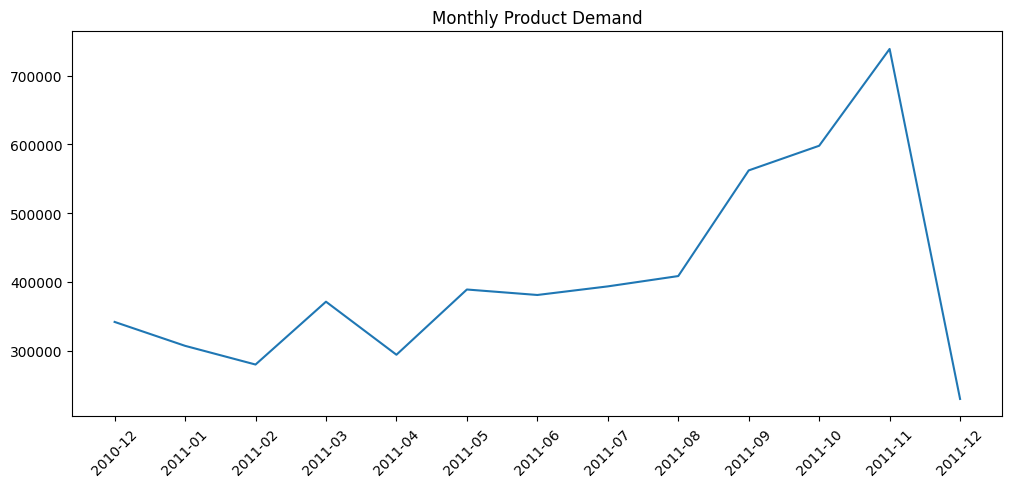

In [77]:
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M")

monthly_product_demand = (
    df.groupby(["YearMonth"])["Quantity"]
      .sum()
      .reset_index()
)

monthly_product_demand["YearMonth"] = monthly_product_demand["YearMonth"].astype(str)

plt.figure(figsize=(12,5))

plt.plot(
    monthly_product_demand["YearMonth"],
    monthly_product_demand["Quantity"]
)

plt.xticks(rotation=45)

plt.title("Monthly Product Demand")

plt.show()

In [78]:
product_summary = df.groupby(
    ["StockCode", "Description"]
).agg({
    "Quantity": "sum",
    "TotalAmount": "sum"
}).reset_index()

product_summary.head()


,StockCode,Description,Quantity,TotalAmount
0,10002,INFLATABLE POLITICAL GLOBE,860,759.89
1,10080,GROOVY CACTUS INFLATABLE,303,119.09
2,10120,DOGGY RUBBER,192,40.32
3,10123C,HEARTS WRAPPING TAPE,5,3.25
4,10124A,SPOTS ON RED BOOKCOVER TAPE,16,6.72


In [79]:
fast_moving = (
    product_summary
    .sort_values("Quantity", ascending=False)
    .head(20)
)

fast_moving[
    ["Description", "Quantity"]
]

,Description,Quantity
3135,WORLD WAR 2 GLIDERS ASSTD DESIGNS,53751
3633,JUMBO BAG RED RETROSPOT,47256
1132,POPCORN HOLDER,36322
3424,ASSORTED COLOUR BIRD ORNAMENT,36282
449,PACK OF 72 RETROSPOT CAKE CASES,36016
3654,WHITE HANGING HEART T-LIGHT HOLDER,35002
2032,RABBIT NIGHT LIGHT,30631
1408,MINI PAINT SET VINTAGE,26437
1531,PACK OF 12 LONDON TISSUES,26095
949,PACK OF 60 PINK PAISLEY CAKE CASES,24719


In [80]:
slow_moving = (
    product_summary
    .sort_values("Quantity")
    .head(20)
)

slow_moving[
    ["Description", "Quantity"]
]

,Description,Quantity
4158,Discount,-1194
4170,SAMPLES,-58
4153,AMAZON FEE,-30
721,ASSORTED TUTTI FRUTTI ROUND BOX,-24
4157,CRUK Commission,-16
4155,Bank Charges,-13
3068,WHITE CHERRY LIGHTS,-8
400,PINK POODLE HANGING DECORATION,-7
583,VINTAGE GOLD TINSEL REEL,-6
166,BLUE PADDED SOFT MOBILE,-6


<Figure size 1200x600 with 0 Axes>

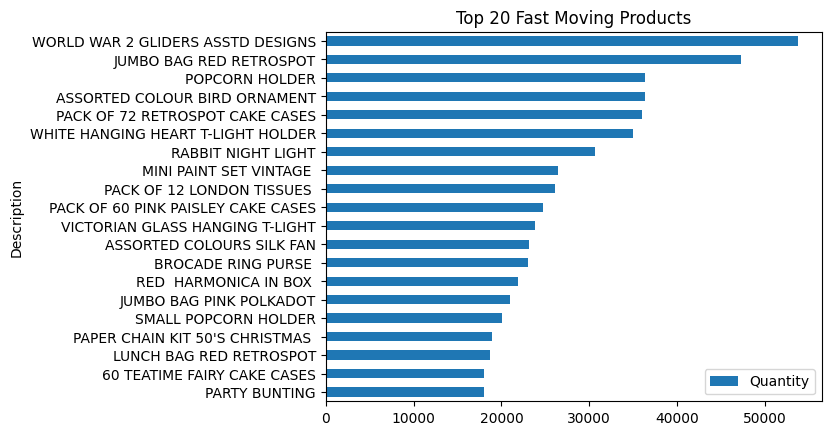

In [81]:
plt.figure(figsize=(12,6))

fast_moving.sort_values("Quantity").plot(
    x="Description",
    y="Quantity",
    kind="barh"
)

plt.title("Top 20 Fast Moving Products")
plt.show()

In [82]:
inventory = df.groupby(
    ["StockCode", "Description"]
)["Quantity"].sum().reset_index()

inventory["Status"] = np.where(
    inventory["Quantity"] < inventory["Quantity"].quantile(0.25),
    "Reorder Needed",
    "Sufficient Stock"
)

inventory.head()

,StockCode,Description,Quantity,Status
0,10002,INFLATABLE POLITICAL GLOBE,860,Sufficient Stock
1,10080,GROOVY CACTUS INFLATABLE,303,Sufficient Stock
2,10120,DOGGY RUBBER,192,Sufficient Stock
3,10123C,HEARTS WRAPPING TAPE,5,Reorder Needed
4,10124A,SPOTS ON RED BOOKCOVER TAPE,16,Reorder Needed


In [83]:
inventory["Status"].value_counts()

,count
Status,
Sufficient Stock,3135
Reorder Needed,1042


In [84]:
inventory["Status"].value_counts()

,count
Status,
Sufficient Stock,3135
Reorder Needed,1042


In [85]:
fast_moving.head()


,StockCode,Description,Quantity,TotalAmount
3135,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,53751,13560.09
3633,85099B,JUMBO BAG RED RETROSPOT,47256,92175.79
1132,22197,POPCORN HOLDER,36322,33959.26
3424,84879,ASSORTED COLOUR BIRD ORNAMENT,36282,58792.42
449,21212,PACK OF 72 RETROSPOT CAKE CASES,36016,21047.07


Inventory Analysis Summary

1. ABC Analysis identified 762 Category A products that contribute the majority of revenue and require strict inventory monitoring.

2. Category B products showed moderate revenue contribution and should be reviewed regularly.

3. Category C products accounted for the largest number of SKUs but generated relatively low revenue, indicating potential opportunities for inventory optimization.

4. Fast-moving products such as WORLD WAR 2 GLIDERS ASSTD DESIGNS and JUMBO BAG RED RETROSPOT exhibited consistently high demand and should be prioritized for replenishment.

5. Inventory status analysis identified 1,042 products requiring reorder attention, while 3,135 products currently maintain sufficient stock levels.

6. These findings can help reduce stockouts, improve inventory turnover, and optimize working capital allocation.
